# Attribute Presence via Semantic Similarity

Semantic similarity (cosine distance) between the reviews and the attribute (keywords and part from groundtruth reviews containing the attribute)




In [1]:
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, recall_score, confusion_matrix
import numpy as np
import seaborn as sns

/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-02-04 15:42:30.964259: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 15:42:30.991975: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To e

### Model choice: sentence-transformers/all-mpnet-base-v2

- Embedding dimension: 764 (can understand nuances)
- Max input tokens: 384 (more than enough for the reviews)
- Very fast (even on a small laptop)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", cache_folder='../../embedding_models').to(device)

### Load data

In [7]:
df_1 = pd.read_csv("../../data/cleaned_data/cleaned_Study_1_reviews.csv")

reviews = df_1["finalReview"].fillna("").tolist() 
reviews[:5]

['My order was to dryclean! All suits came back in dirty and smelly! And this like 5th time happwning!And i made a note to take extra care! I demand a refund and u have lost me as a customer! Ur service became disguating! I will makw sure my friends leave u',
 'poor experience. jacket not cleaned properly.',
 'The clean laundry came in a bag that had a smell. Even though it was inside a white plastic bag, reusing and mixing dirty bags to carry clean clothes is not ideal.',
 'not happy with the service. i received multiple emails asking if the quotation to clean my two dresses is approved as they were quoted at 120 dhs per dress and i replied to each message asking to proceed and finally my order was cancelled and items return',
 'its a very expensive service.']

### Reviews and Groundtruth embedding

For the groundtruth, I tried with only the name of the attributes, with description of the attributes or with relevant part of reviews/keywords.
The last approach is the one that works best.

NOTE: keywords and sample from reviews among the first 100, and then validation on the last 100, so no leakage

In [8]:
attribute_names = [
    'cleaning_service_quality',
    'order_packaging',
    'communication_and_responsiveness',
    'Driver_professionalism',
    'Service_speed'
]

reviews_example = [
    "the cloths are nor ironed, My shirts came back wrinkled still, my order was to dryclean! All suits came back in dirty and smelly! Items have come back still dirty",
    "The clean laundry came in a bag that had a smell. Even though it was inside a white plastic bag, reusing and mixing dirty bags to carry clean clothes is not ideal, i had specifically asked that all clothes be returned folded in individual plastic bags and they have been sent on hangers.",
    "i received multiple emails asking if the quotation to clean my two dresses is approved as they were quoted at 120 dhs per dress and i replied to each message asking to proceed and finally my order was cancelled and items return. I have been issued a refund in both cases but could do without the hassle. i have contacted you and sent photos,  you offer a pathetic small credit",
    "polite, your drivers are always super nice and very professional, drivers extremely friendly",
    "slow, prompt, efficient, fast. took less than 24 hours, 2 days. I had a lot of delays. Very prompt pickup, collect and the delivery was ahead of schedule, hasn't arrived yet"
]

review_embeddings = model.encode(reviews, convert_to_tensor=True, show_progress_bar=True)
attr_embeddings = model.encode(reviews_example, convert_to_tensor=True)


Batches: 100%|██████████| 82/82 [00:03<00:00, 27.27it/s]


### Evaluation on the last 100 reviews

We use the AUC to evaluate the method and the groundtruth choice

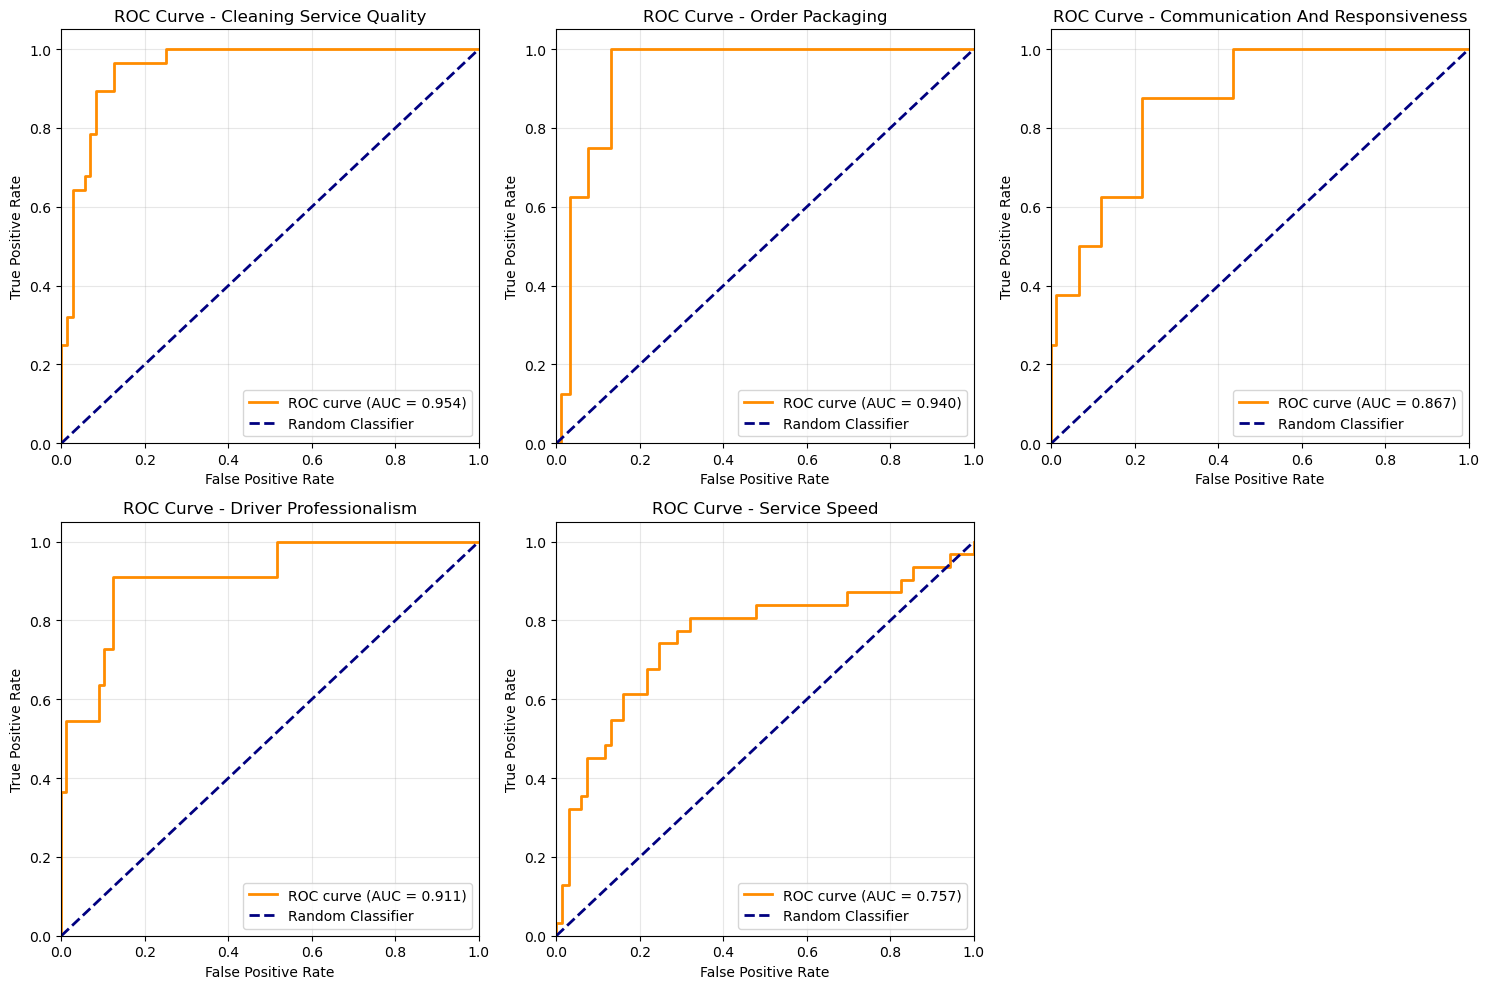


AUC Scores for Each Attribute:
Cleaning Service Quality                 AUC = 0.9539
Order Packaging                          AUC = 0.9402
Communication And Responsiveness         AUC = 0.8668
Driver Professionalism                   AUC = 0.9111
Service Speed                            AUC = 0.7574


In [10]:
valid_df = pd.read_csv('../../data/labeled_presence/label_Study_1_reviews.csv')
valid_df = valid_df.iloc[2502:,:] # Validation on the last 100 (hand-labeled)

valid_review_embeddings = model.encode(
    valid_df["finalReview"].fillna("").tolist(), 
    convert_to_tensor=True
)
valid_cosine_scores = util.cos_sim(valid_review_embeddings, attr_embeddings)
valid_scores = valid_cosine_scores.cpu().numpy()

# Plot ROC curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve - {attr_name.replace("_", " ").title()}')
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

# Remove the extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('roc_curves_all_attributes.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print("\n" + "="*60)
print("AUC Scores for Each Attribute:")
print("="*60)
for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    roc_auc = roc_auc_score(y_true, y_scores)
    print(f"{attr_name.replace('_', ' ').title():<40} AUC = {roc_auc:.4f}")

### Get the optimal selection threshold

In [11]:
print("\n" + "="*60)
print("Optimal Thresholds (Youden's J statistic):")
print("="*60)

optimal_thresholds = []

for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Youden's J statistic: maximize (TPR - FPR)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    optimal_thresholds.append(optimal_threshold)
    
    print(f"{attr_name.replace('_', ' ').title():<40} Threshold = {optimal_threshold:.4f}")


Optimal Thresholds (Youden's J statistic):
Cleaning Service Quality                 Threshold = 0.2094
Order Packaging                          Threshold = 0.3296
Communication And Responsiveness         Threshold = 0.3485
Driver Professionalism                   Threshold = 0.3290
Service Speed                            Threshold = 0.2749


In [12]:
cosine_scores = util.cos_sim(review_embeddings, attr_embeddings)
cosine_scores_np = cosine_scores.cpu().numpy()

predictions = np.zeros_like(cosine_scores_np, dtype=int)
# Use the optimal thresolds obtained above
for i, threshold in enumerate(optimal_thresholds):
    predictions[:, i] = (cosine_scores_np[:, i] > threshold).astype(int)

for i, attr_name in enumerate(attribute_names):
    col_name = attr_name
    df_1[col_name] = predictions[:, i]

df_1.head()

,ID,finalReview,Satisfaction_final,cleaning_service_quality,order_packaging,communication_and_responsiveness,Driver_professionalism,Service_speed,cleaning_service_quality_sentiment,order_packaging_sentiment,communication_and_responsiveness_sentiment,Driver_professionalism_sentiment,Service_speed_sentiment,Overall_review_sentiment,Emotional_intensity_LLM,lang
0,1,My order was to dryclean! All suits came back ...,1.0,1,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en
1,2,poor experience. jacket not cleaned properly.,2.5,1,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en
2,3,The clean laundry came in a bag that had a sme...,4.5,1,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en
3,4,not happy with the service. i received multipl...,3.0,1,1,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en
4,5,its a very expensive service.,3.5,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en


Percentage reviews well classified for all attributes:
 - Overall: 0.4100

Accuracy Scores per Attribute:
 - cleaning_service_quality: 0.8900
 - order_packaging: 0.8700
 - communication_and_responsiveness: 0.7900
 - Driver_professionalism: 0.8800
 - Service_speed: 0.7400
Recall Scores per Attribute:
 - cleaning_service_quality: 0.9286
 - order_packaging: 0.8750
 - communication_and_responsiveness: 0.8750
 - Driver_professionalism: 0.9091
 - Service_speed: 0.7097


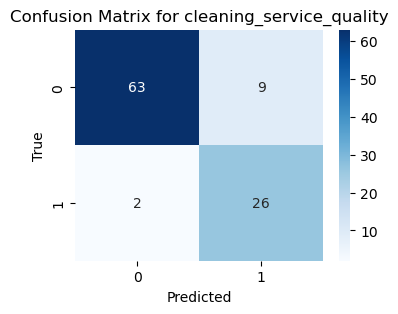

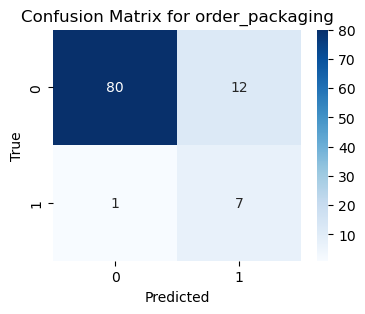

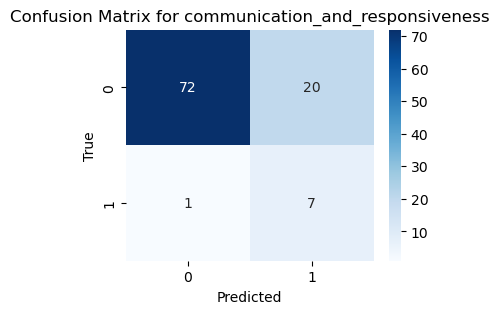

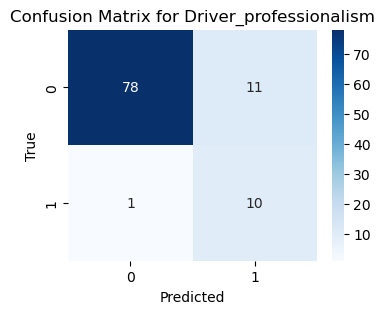

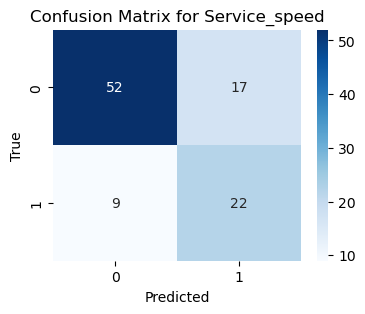

In [ ]:
pred_df =  df_1.iloc[2502:,:]

accuracy_scores = {}
recall_scores = {}
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[attr_name].astype(int).tolist()[:len(y_true)]
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy_scores[attr_name] = accuracy
    recall_scores[attr_name] = recall

print("Percentage reviews well classified for all attributes:")
well_classified = (pred_df[attribute_names].astype(int).values == valid_df[attribute_names].astype(int).values).all(axis=1).mean()
print(f" - Overall: {well_classified:.4f}\n")

print("Accuracy Scores per Attribute:")
for attr_name, score in accuracy_scores.items():
    print(f" - {attr_name}: {score:.4f}")

print("Recall Scores per Attribute:")
for attr_name, score in recall_scores.items():
    print(f" - {attr_name}: {score:.4f}")

# create a confusion matrix for each attribute
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[attr_name].astype(int).tolist()[:len(y_true)]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'Confusion Matrix for {attr_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


In [15]:
df_1.to_csv("../../data/predicted_attributes/predicted_Study_1_reviews.csv")